# False intersection lens in `eunoia` Euler layouts

**Symptom.** A 3-set diagram draws a large, obvious overlap between two sets that share
**zero** members. In VISET the lens renders blank — no count, no member list — because
there is nothing to put in it. It reads as "an intersection whose label failed to render",
but the truth is the opposite: the *count* is right (there is no intersection) and the
*geometry* is wrong.

**Scope.** This is an upstream `eunoia` layout-fit issue, not a VISET labelling bug.
Cells 3-4 below reproduce it with `eunoia` alone, no VISET involved.

**Trigger.** Two sets that are each largely *nested* inside a third, and that share nothing
with each other. Two ellipses cannot each fill half of a containing ellipse without
crossing, so the fit is unsatisfiable and the residual error surfaces as a false lens.
Sets that are merely *disjoint* are laid out correctly — see the control at the end.

## 1. Environment

In [1]:
import sys, importlib.metadata as md
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from matplotlib.path import Path
import eunoia as eu

for p in ("eunoia", "matplotlib", "numpy", "pandas", "scipy"):
    try:    print(f"{p:12s} {md.version(p)}")
    except Exception: print(f"{p:12s} not found")
print(f"{'python':12s} {sys.version.split()[0]}")

eunoia       0.5.0
matplotlib   3.11.0
numpy        2.2.6
pandas       2.3.3
scipy        1.17.1
python       3.11.15


## 2. The dataset

Two 66-member modules, each with 60 of its members inside a 125-member pathway.
The two modules share **nothing**.

In [2]:
onlyA = [f"AX{i}" for i in range(6)]    # ModuleA exclusive
onlyB = [f"BX{i}" for i in range(6)]    # ModuleB exclusive
onlyC = [f"CX{i}" for i in range(5)]    # Pathway exclusive
AC    = [f"ac{i}" for i in range(60)]   # ModuleA members inside Pathway
BC    = [f"bc{i}" for i in range(60)]   # ModuleB members inside Pathway

A = onlyA + AC          # ModuleA
B = onlyB + BC          # ModuleB
C = onlyC + AC + BC     # Pathway

sets = {"ModuleA": set(A), "ModuleB": set(B), "Pathway": set(C)}
for k, v in sets.items():
    print(f"{k:9s} n={len(v)}")

shared = sets["ModuleA"] & sets["ModuleB"]
print(f"\nModuleA & ModuleB shared members: {len(shared)}  ->  {shared or '{}'}")
assert len(shared) == 0, "the two modules must be disjoint for this repro"

ModuleA   n=66
ModuleB   n=66
Pathway   n=125

ModuleA & ModuleB shared members: 0  ->  {}


## 3. Measure what actually gets drawn

`fit.plot_data["shape_outlines"]` gives the polygon VISET rasterises. Rather than trusting
`fitted_values`, sample the plane and measure the true drawn overlap of the two module
shapes, as a fraction of the smaller one.

In [3]:
def drawn_lens_fraction(fit, a, b, n=500):
    """Fraction of the smaller shape covered by the drawn a&b overlap."""
    o = fit.plot_data["shape_outlines"]
    allp = np.vstack([np.asarray(o[k]) for k in o])
    gx = np.linspace(allp[:, 0].min(), allp[:, 0].max(), n)
    gy = np.linspace(allp[:, 1].min(), allp[:, 1].max(), n)
    GX, GY = np.meshgrid(gx, gy)
    P = np.column_stack([GX.ravel(), GY.ravel()])
    ma = Path(np.asarray(o[a])).contains_points(P)
    mb = Path(np.asarray(o[b])).contains_points(P)
    return (ma & mb).sum() / max(min(ma.sum(), mb.sum()), 1)


data = {k: sorted(v) for k, v in sets.items()}
fits = {}
print(f"{'shape':9s} {'diag_error':>10s} {'stress':>8s} {'drawn ModuleA&ModuleB':>22s}   (real = 0)")
for shape in ("circle", "ellipse"):
    f = eu.euler(data, shape=shape, seed=0)
    fits[shape] = f
    frac = drawn_lens_fraction(f, "ModuleA", "ModuleB")
    print(f"{shape:9s} {f.diag_error:10.3f} {f.stress:8.3f} {frac*100:21.1f}%")

shape     diag_error   stress  drawn ModuleA&ModuleB   (real = 0)


circle         0.147    0.145                  18.2%


ellipse        0.141    0.188                  29.3%


Both layouts draw a substantial overlap between two sets whose intersection is empty.

Neither shape is reliably safer: on this dataset ellipses are worse (29.3% vs 18.2%), but
on other configurations in the sweep in section 7 circles are worse, and on several both
are clean. Switching `style` is therefore **not** a fix — it just moves the failure around.

Note also that `fitted_values` **agrees** there is no intersection — it reports no
`ModuleA&ModuleB` region at all. The error is purely in the returned geometry.

In [4]:
for shape, f in fits.items():
    print(shape)
    print("   requested:", {k: round(v) for k, v in f.original_values.items()})
    print("   fitted   :", {k: round(v, 1) for k, v in f.fitted_values.items()})

circle
   requested: {'ModuleA&Pathway': 60, 'ModuleA': 6, 'ModuleB&Pathway': 60, 'ModuleB': 6, 'Pathway': 5}
   fitted   : {'ModuleA&Pathway': 49.4, 'ModuleA': 14.9, 'ModuleB&Pathway': 49.4, 'ModuleB': 14.9, 'Pathway': 26.7}
ellipse
   requested: {'ModuleA&Pathway': 60, 'ModuleA': 6, 'ModuleB&Pathway': 60, 'ModuleB': 6, 'Pathway': 5}
   fitted   : {'ModuleA&Pathway': 40.7, 'ModuleA': 6.0, 'ModuleB&Pathway': 40.7, 'ModuleB': 6.0, 'Pathway': 24.3}


## 4. Plot with `eunoia` alone (no VISET)

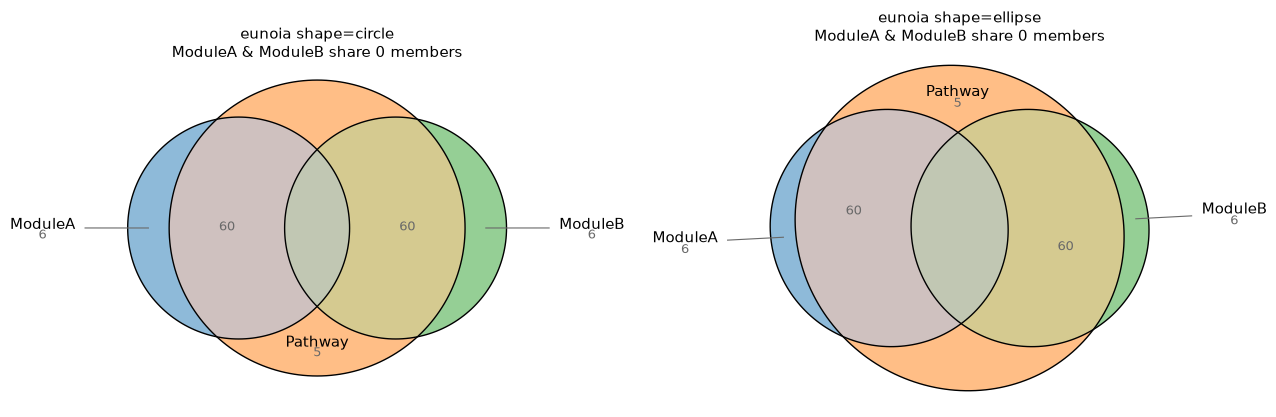

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (shape, f) in zip(axes, fits.items()):
    f.plot(ax=ax, quantities=True, legend=False)
    ax.set_title(f"eunoia shape={shape}\nModuleA & ModuleB share 0 members", fontsize=11)
plt.tight_layout(); plt.show()

The lens between the two module shapes is drawn despite the intersection being empty.
This is the bug, and it is entirely upstream of VISET.

## 5. The same thing through VISET

VISET computes its counts from real set membership, so it correctly finds nothing to put
in that region — and `viset/venn.py:191` (`if not s: continue`) skips labelling it. The
false lens therefore renders as a **blank grey area with no count**.

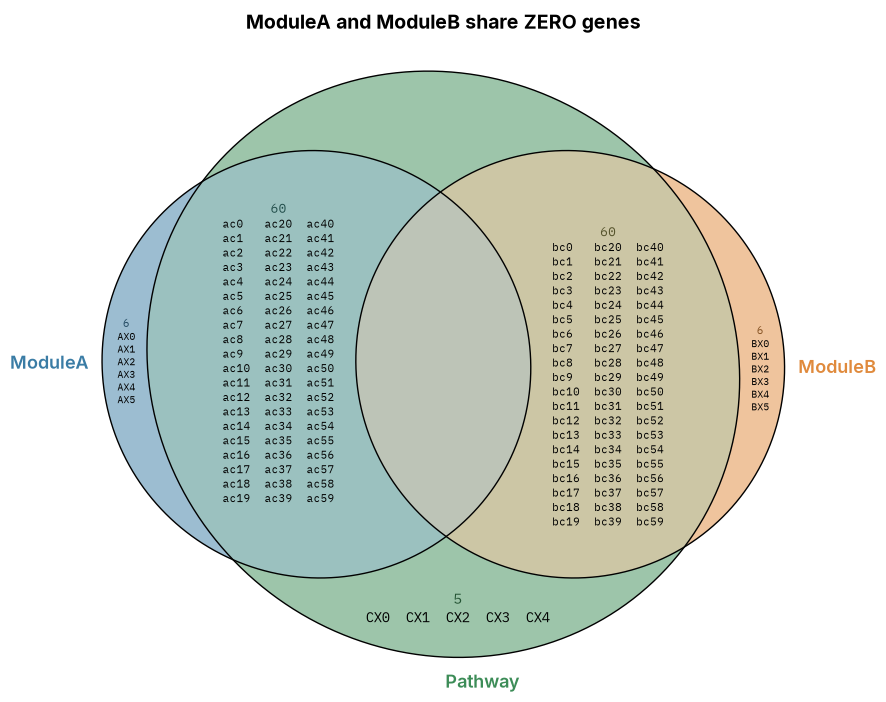

In [6]:
sys.path.insert(0, "..")   # adjust if you moved this notebook
from viset import eunoia_venn

dfs = [pd.DataFrame({"ModuleA": A}),
       pd.DataFrame({"ModuleB": B}),
       pd.DataFrame({"Pathway": C})]

eunoia_venn(dfs, colors=["#3a7ca5", "#e08a3c", "#3c8c57"],
            title="ModuleA and ModuleB share ZERO genes", figsize=(11, 8.5))

Look at the centre: a large grey lens with no number and no members. Every count that
*is* printed is correct. Only the geometry misleads.

## 6. Control — genuinely disjoint sets lay out correctly

To show the layout engine is not simply careless about disjointness: a third set that
shares nothing with either of the other two, and is not nested, gets its own free-standing
shape with a clean gap.

diag_error: 0.0  stress: 0.0
   Alpha  centre_x=  -6.31  r=4.37
   Beta   centre_x=  -1.48  r=4.37
   Gamma  centre_x=   7.11  r=3.57



Alpha&Gamma drawn overlap: 0.0%


Beta&Gamma  drawn overlap: 0.0%


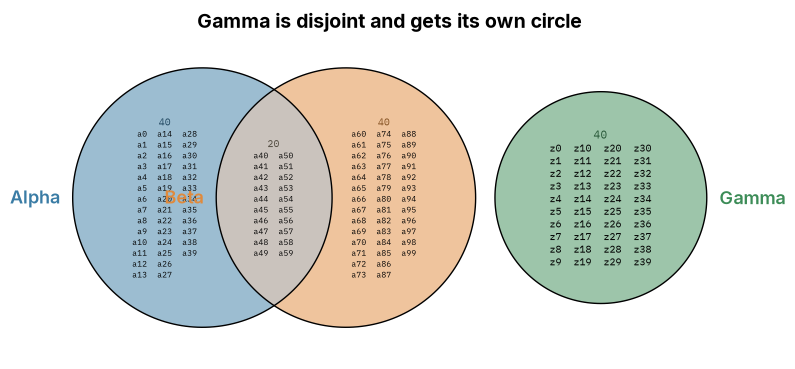

In [7]:
ctrl = {"Alpha": [f"a{i}" for i in range(0, 60)],
        "Beta":  [f"a{i}" for i in range(40, 100)],
        "Gamma": [f"z{i}" for i in range(0, 40)]}

f = eu.euler({k: sorted(v) for k, v in ctrl.items()}, shape="circle", seed=0)
print("diag_error:", round(f.diag_error, 4), " stress:", round(f.stress, 4))
for s in f.shapes:
    print(f"   {s.set:6s} centre_x={s.center.x:7.2f}  r={s.radius:.2f}")
print("\nAlpha&Gamma drawn overlap:", f"{drawn_lens_fraction(f,'Alpha','Gamma')*100:.1f}%")
print("Beta&Gamma  drawn overlap:", f"{drawn_lens_fraction(f,'Beta','Gamma')*100:.1f}%")

eunoia_venn([pd.DataFrame({k: v}) for k, v in ctrl.items()],
            colors=["#3a7ca5", "#e08a3c", "#3c8c57"],
            title="Gamma is disjoint and gets its own circle", figsize=(9, 6))

## 7. How often does this happen?

A small sweep over the nested family. `cfg` is the requested region sizes
`(A_only, B_only, C_only, A&B, A&C, B&C, A&B&C)`; every config here has `A&B = 0`,
so any drawn lens is false.

In [8]:
def build(oa, ob, oc, ab, ac, bc, abc):
    it = iter(range(100000)); take = lambda n: [next(it) for _ in range(n)]
    A_, B_, C_ = take(oa), take(ob), take(oc)
    Iab, Iac, Ibc, Iabc = take(ab), take(ac), take(bc), take(abc)
    return {"A": sorted(set(A_+Iab+Iac+Iabc)),
            "B": sorted(set(B_+Iab+Ibc+Iabc)),
            "C": sorted(set(C_+Iac+Ibc+Iabc))}

print(f"{'cfg':>28s} {'sizes':>20s} {'circle':>9s} {'ellipse':>9s}")
for cfg in [(6, 6, 5, 0, 60, 60, 0), (3, 3, 0, 0, 80, 80, 0), (10, 10, 0, 0, 80, 80, 0),
            (6, 6, 30, 0, 40, 40, 0), (15, 15, 15, 0, 40, 40, 0), (10, 10, 30, 0, 20, 20, 0),
            (20, 20, 40, 0, 10, 10, 0), (30, 30, 5, 0, 10, 10, 0)]:
    d = build(*cfg)
    sizes = f"{len(d['A'])}/{len(d['B'])}/{len(d['C'])}"
    row = []
    for shape in ("circle", "ellipse"):
        f = eu.euler(d, shape=shape, seed=0)
        row.append(f"{drawn_lens_fraction(f, 'A', 'B', n=300)*100:8.1f}%")
    print(f"{str(cfg):>28s} {sizes:>20s} {row[0]:>9s} {row[1]:>9s}")

                         cfg                sizes    circle   ellipse


     (6, 6, 5, 0, 60, 60, 0)            66/66/125     18.2%     29.3%


     (3, 3, 0, 0, 80, 80, 0)            83/83/160     20.1%     35.2%


   (10, 10, 0, 0, 80, 80, 0)            90/90/160     18.6%     30.2%
    (6, 6, 30, 0, 40, 40, 0)            46/46/110      8.0%      0.0%


  (15, 15, 15, 0, 40, 40, 0)             55/55/95      9.8%      0.0%
  (10, 10, 30, 0, 20, 20, 0)             30/30/70      0.0%      0.0%


  (20, 20, 40, 0, 10, 10, 0)             30/30/60      0.0%      0.0%
   (30, 30, 5, 0, 10, 10, 0)             40/40/25      0.0%      0.0%


Failure scales with how deeply A and B are nested inside C. Once the modules carry
enough exclusive members to sit outside the pathway, the fit becomes satisfiable and the
false lens disappears.

## 8. Summary

- `eunoia` returns shape geometry that overlaps for sets with an empty intersection, when
  those sets are largely nested inside a third set. `diag_error` is non-zero and correctly
  flags the poor fit; the returned outlines are simply the least-bad compromise.
- `fitted_values` reports no intersection, so the fit object is self-inconsistent with its
  own geometry — a useful detection hook.
- VISET's counts are unaffected. The only VISET-side issue is that `venn.py:191` skips
  labelling empty regions, so a false lens renders blank rather than being flagged.

**Suggested VISET mitigation:** at the `if not s: continue` branch, test the region mask
that is already built at `venn.py:186`. If an empty region has a non-trivial drawn area,
emit a `UserWarning` naming the pair and draw an explicit `0`, so the figure never
silently implies membership.